# Gradient Descent and Loss Functions

**Unit:** Unit 3: AI Concepts, Terminology, and Application Domains Part 2

In notebook `01_regression_classification.ipynb` we called `LinearRegression()` and `LogisticRegression()` and sklearn fitted them for us -- but *how* does a model actually find good parameters? Every trainable model in this diploma (from linear regression to deep neural networks) learns the same way: define a **loss function** that measures how wrong the model is, then use **gradient descent** to repeatedly nudge the parameters in the direction that reduces that loss. In this lab we open the black box and implement both pieces by hand in NumPy, so that when Keras prints `loss:` during training later in the course, you know exactly what is happening.

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Mean Squared Error (MSE) and its gradient in pure NumPy
- Write a gradient descent loop and watch the loss shrink step by step
- See experimentally what happens when the learning rate is too small, good, or too large
- Implement binary cross-entropy loss and train a logistic regression with it
- Know when to use MSE vs cross-entropy

---

## 1. Fitting a Line by Hand: MSE + Gradient Descent

**The setup.** We generate a small 1-feature dataset from a known "true" line `y = 3x + 4 + noise`. Our model is `y_pred = w*x + b` and we start from the worst possible guess: `w = 0, b = 0`.

**The loss.** Mean Squared Error averages the squared distance between predictions and truth:

$$\mathrm{MSE}(w, b) = \frac{1}{n}\sum_{i=1}^{n} (w x_i + b - y_i)^2$$

**The gradient.** Calculus gives us the direction of steepest *increase* of the loss, so we step the opposite way:

$$\frac{\partial \mathrm{MSE}}{\partial w} = \frac{2}{n}\sum_i (w x_i + b - y_i)\,x_i \qquad \frac{\partial \mathrm{MSE}}{\partial b} = \frac{2}{n}\sum_i (w x_i + b - y_i)$$

Each iteration: `w = w - lr * dw` and `b = b - lr * db`. That is the entire algorithm.

In [1]:
# Gradient descent from scratch on a line-fitting problem: define the MSE loss, derive
# its gradients, and repeatedly step downhill — no ML library involved, every number visible.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Small synthetic dataset: y = 3x + 4 + noise
n = 60
x = np.random.uniform(0, 2, n)
y = 3 * x + 4 + np.random.normal(0, 0.5, n)
print(f"Dataset: {n} points, 1 feature (true line: y = 3x + 4, noise std = 0.5)")


def mse_loss(w, b, x, y):
    """Mean Squared Error of the line y_pred = w*x + b."""
    error = (w * x + b) - y
    return np.mean(error ** 2)


def mse_gradients(w, b, x, y):
    """Partial derivatives of MSE with respect to w and b."""
    error = (w * x + b) - y
    dw = 2 * np.mean(error * x)
    db = 2 * np.mean(error)
    return dw, db


# Gradient descent loop
# The learning loop: start from w=b=0 and take 200 small steps against the gradient.
w, b = 0.0, 0.0
lr = 0.1
steps = 200
loss_history = []

print(f"\nGradient descent: lr = {lr}, {steps} steps, start w = 0, b = 0")
print(f"{'step':>5} {'loss (MSE)':>12} {'w':>8} {'b':>8}")
for step in range(steps + 1):
    loss = mse_loss(w, b, x, y)
    loss_history.append(loss)
    if step % 20 == 0:
        print(f"{step:>5} {loss:>12.4f} {w:>8.3f} {b:>8.3f}")
    dw, db = mse_gradients(w, b, x, y)
    w -= lr * dw
    b -= lr * db

print(f"\nLearned line:  y = {w:.3f}x + {b:.3f}")
print(f"True line:     y = 3x + 4")
print(f"Final MSE: {loss_history[-1]:.4f}  (close to the noise variance 0.5^2 = 0.25 -- "
      "the irreducible error)")

Dataset: 60 points, 1 feature (true line: y = 3x + 4, noise std = 0.5)

Gradient descent: lr = 0.1, 200 steps, start w = 0, b = 0
 step   loss (MSE)        w        b
    0      49.0245    0.000    0.000
   20       0.2458    3.265    3.638
   40       0.2059    3.080    3.847
   60       0.1965    2.991    3.949
   80       0.1943    2.948    3.998
  100       0.1938    2.927    4.022
  120       0.1937    2.917    4.033
  140       0.1937    2.912    4.039
  160       0.1937    2.909    4.042
  180       0.1937    2.908    4.043
  200       0.1937    2.908    4.044

Learned line:  y = 2.908x + 4.044
True line:     y = 3x + 4
Final MSE: 0.1937  (close to the noise variance 0.5^2 = 0.25 -- the irreducible error)


The printed table shows the loss collapsing from **~49.0 at step 0** (the line `y = 0` misses everything) to **~0.19 at step 200**, and the learned parameters land near the true `w = 3, b = 4`. The loss cannot reach zero: the data was generated with noise of variance 0.25, so the loss plateaus at the irreducible error (~0.19 happens to be the best achievable on this particular 60-point sample) -- that plateau is a *perfect* fit, not a failure.

### Visualize: loss curve and fitted line

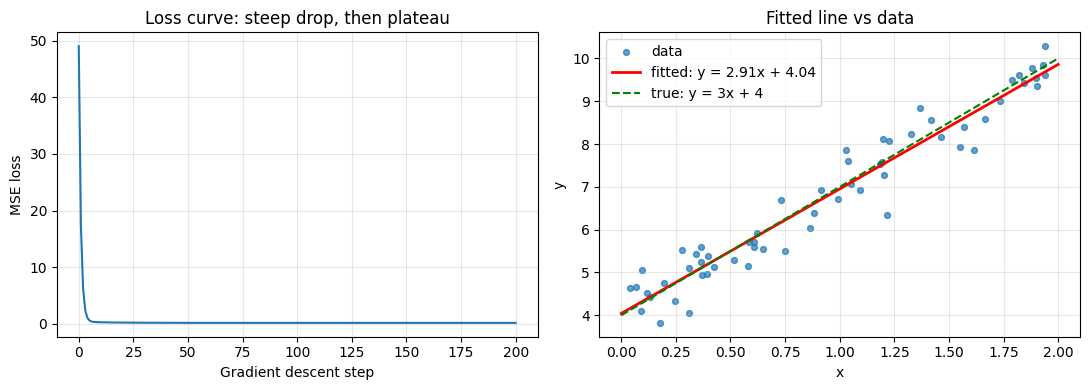

Left: most of the loss disappears in the first ~30 steps, then progress flattens.
Right: the fitted (red) line sits on top of the true (green dashed) line.


In [2]:
# Visual check of what training just did: the loss curve (left) and the fitted line
# on top of the data (right) — the two plots you should draw after ANY training run.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
ax1.plot(loss_history, color='tab:blue')
ax1.set_xlabel('Gradient descent step')
ax1.set_ylabel('MSE loss')
ax1.set_title('Loss curve: steep drop, then plateau')
ax1.grid(alpha=0.3)

# Data + fitted line
xs = np.linspace(0, 2, 100)
ax2.scatter(x, y, s=18, alpha=0.7, label='data')
ax2.plot(xs, w * xs + b, 'r-', lw=2, label=f'fitted: y = {w:.2f}x + {b:.2f}')
ax2.plot(xs, 3 * xs + 4, 'g--', lw=1.5, label='true: y = 3x + 4')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Fitted line vs data')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: most of the loss disappears in the first ~30 steps, then progress flattens.")
print("Right: the fitted (red) line sits on top of the true (green dashed) line.")

## 2. Comparative Experiment: the Learning Rate

The gradient tells us the *direction* to move; the learning rate `lr` decides the *step size*. We now change **exactly one thing** -- the learning rate -- and re-run the identical gradient descent loop three times on the same data, same start point, same 200 steps:

| run | lr | expectation |
|-----|------|-------------|
| too small | 0.001 | crawls -- barely reduces the loss |
| good | 0.1 | converges to the noise floor |
| too large | 1.2 | overshoots -- loss explodes |

=== Learning rate comparison (same data, same start, 200 steps) ===
      run  learning rate  steps taken           final loss    status
too small          0.001          200               9.6836 converged
     good          0.100          200               0.1937 converged
too large          1.200            8 172,086,505,475.6717  DIVERGED


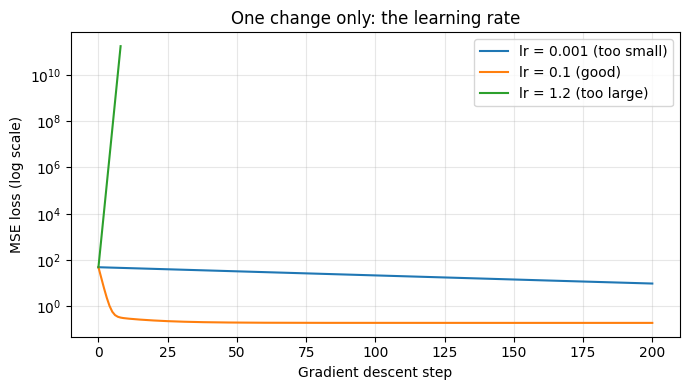

In [3]:
# The learning rate is the one knob that makes or breaks gradient descent: too small
# crawls, too large explodes. Same data, same start — only lr changes.
def run_gradient_descent(lr, steps=200):
    """Run GD from w=b=0; stop early if the loss blows up. Returns loss history + status."""
    w, b = 0.0, 0.0
    history = []
    for step in range(steps + 1):
        loss = mse_loss(w, b, x, y)
        if not np.isfinite(loss) or loss > 1e12:
            return history, 'DIVERGED'
        history.append(loss)
        dw, db = mse_gradients(w, b, x, y)
        w -= lr * dw
        b -= lr * db
    return history, 'converged'


# Three runs that differ ONLY in learning rate — compare their loss histories.
experiments = {'too small': 0.001, 'good': 0.1, 'too large': 1.2}
results = []
histories = {}
for name, lr_i in experiments.items():
    hist, status = run_gradient_descent(lr_i)
    histories[name] = hist
    results.append({'run': name, 'learning rate': lr_i,
                    'steps taken': len(hist) - 1,
                    'final loss': hist[-1], 'status': status})

summary = pd.DataFrame(results)
print("=== Learning rate comparison (same data, same start, 200 steps) ===")
print(summary.to_string(index=False,
                        formatters={'final loss': lambda v: f'{v:,.4f}'}))

# Loss curves on a log scale so all three runs fit on one plot
plt.figure(figsize=(7, 4))
for name, hist in histories.items():
    plt.plot(hist, label=f"lr = {experiments[name]} ({name})")
plt.yscale('log')
plt.xlabel('Gradient descent step')
plt.ylabel('MSE loss (log scale)')
plt.title('One change only: the learning rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion from the table above:**

- **lr = 0.001 (too small)** never diverges but after 200 steps the loss is still ~9.7 -- it moved in the right direction the whole time, just in tiny steps. It would eventually get there, but "eventually" can mean thousands of steps.
- **lr = 0.1 (good)** reaches ~0.19, the irreducible-noise floor -- the same result as Section 1.
- **lr = 1.2 (too large) is the run that diverged**: its loss exceeded 10^12 after only **8 steps** and the loop stopped early. **Why:** each update is `lr * gradient`. When the step is more than twice the distance to the minimum, the parameters land *farther* from the optimum than where they started, which makes the next gradient even bigger -- so every step overshoots by more than the last and the loss grows exponentially (a straight climbing line on the log-scale plot).

This is why "my loss is NaN/exploding" in deep learning almost always means *lower the learning rate first*.

## 3. Cross-Entropy: the Loss for Classification

MSE measures distance between *numbers*, which is right for regression. For classification the model outputs a **probability** and the labels are 0/1 -- so we instead use **binary cross-entropy (BCE)**, which heavily punishes confident wrong answers:

$$\mathrm{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(p_i) + (1 - y_i)\log(1 - p_i)\Big], \qquad p_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$$

Predicting `p = 0.01` for a true 1 costs `-log(0.01) ≈ 4.6`; predicting `p = 0.99` costs only `-log(0.99) ≈ 0.01`. We train the exact same way -- compute gradient, step downhill -- only the loss function changed. This is literally what sklearn's `LogisticRegression` (used in notebook 01) minimizes internally.

Dataset: 80 points, 2 features, classes: [40 40] (class 0 / class 1)

Gradient descent on cross-entropy: lr = 0.5, 300 steps
 step   loss (BCE)  accuracy
    0       0.6931    50.00%
   50       0.1059    98.75%
  100       0.0737    98.75%
  150       0.0607    98.75%
  200       0.0533    98.75%
  250       0.0485    98.75%
  300       0.0449    98.75%

BCE went from 0.6931 (random guessing: -log(0.5) = 0.693) to 0.0449
Final training accuracy: 98.75%


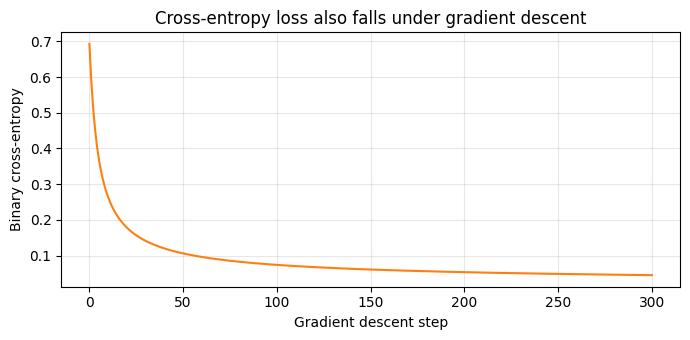

In [4]:
# Same algorithm, different loss: swap MSE for binary cross-entropy and the identical
# update loop now trains a CLASSIFIER — losses are plug-ins, gradient descent is universal.
from sklearn.datasets import make_blobs

# Tiny 2-class dataset: 80 points, 2 features
X, y_cls = make_blobs(n_samples=80, centers=2, cluster_std=1.8, random_state=7)
X = (X - X.mean(axis=0)) / X.std(axis=0)   # standardize for stable gradient descent
print(f"Dataset: {X.shape[0]} points, {X.shape[1]} features, "
      f"classes: {np.bincount(y_cls)} (class 0 / class 1)")


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def bce_loss(w_vec, b, X, y):
    """Binary cross-entropy of logistic model p = sigmoid(Xw + b)."""
    p = sigmoid(X @ w_vec + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)   # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def bce_gradients(w_vec, b, X, y):
    """Gradient of BCE -- same shape of update rule as MSE, different loss."""
    p = sigmoid(X @ w_vec + b)
    dw = X.T @ (p - y) / len(y)
    db = np.mean(p - y)
    return dw, db


# The very same loop as Section 1 -- only the loss/gradient functions changed
w_vec = np.zeros(X.shape[1])
b = 0.0
lr = 0.5
steps = 300
bce_history = []

print(f"\nGradient descent on cross-entropy: lr = {lr}, {steps} steps")
print(f"{'step':>5} {'loss (BCE)':>12} {'accuracy':>9}")
for step in range(steps + 1):
    loss = bce_loss(w_vec, b, X, y_cls)
    bce_history.append(loss)
    if step % 50 == 0:
        acc = np.mean((sigmoid(X @ w_vec + b) >= 0.5) == y_cls)
        print(f"{step:>5} {loss:>12.4f} {acc:>9.2%}")
    dw, db = bce_gradients(w_vec, b, X, y_cls)
    w_vec -= lr * dw
    b -= lr * db

final_acc = np.mean((sigmoid(X @ w_vec + b) >= 0.5) == y_cls)
print(f"\nBCE went from {bce_history[0]:.4f} (random guessing: -log(0.5) = 0.693) "
      f"to {bce_history[-1]:.4f}")
print(f"Final training accuracy: {final_acc:.2%}")

plt.figure(figsize=(7, 3.5))
plt.plot(bce_history, color='tab:orange')
plt.xlabel('Gradient descent step')
plt.ylabel('Binary cross-entropy')
plt.title('Cross-entropy loss also falls under gradient descent')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The starting loss is exactly **0.6931 = -log(0.5)**: with `w = 0` the model outputs probability 0.5 for everyone, i.e. pure guessing. Gradient descent drives BCE down to **~0.045** and training accuracy up to **98.75%** -- the same "compute gradient, step downhill" loop as Section 1, with only the loss function swapped.

## 4. Wrap-Up: When MSE, When Cross-Entropy?

| | **MSE** | **Cross-Entropy** |
|---|---|---|
| Task | Regression (continuous outputs) | Classification (probabilities) |
| Measures | Squared distance to the target number | How much probability you gave the true class |
| Penalizes | Big numeric errors quadratically | Confident wrong predictions (near-)infinitely |
| Seen in this unit | `LinearRegression` + MSE in `01_regression_classification.ipynb` | `LogisticRegression` in `01_regression_classification.ipynb` minimizes exactly this |

**Connecting back to notebook 01:** there, `mean_squared_error(y_test, y_pred)` evaluated the house-price regressor and `LogisticRegression` classified spam -- sklearn hid the optimization. Today you implemented the machinery underneath: **loss + gradient + learning rate = training**. Keep the learning-rate experiment in mind -- it is the single most common knob you will tune for the rest of this diploma, and "loss exploded" almost always means the step size, not the model, is wrong.

### 🔑 Key Takeaways
- Training = minimizing a loss function with gradient descent
- MSE for regression; cross-entropy for classification -- the loop itself is identical
- Learning rate too small: slow crawl; too large: exponential divergence
- A loss plateau near the noise floor is success, not failure

## 📚 References

1. Robbins, H., & Monro, S. (1951). *A Stochastic Approximation Method*. Annals of Mathematical Statistics, 22(3), 400–407.
2. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
3. Ruder, S. (2016). *An overview of gradient descent optimization algorithms*. arXiv. <https://arxiv.org/abs/1609.04747>